# Bradgley Rodríguez: Pitch Usage vs Whiff Rate

Is he underusing pitches that are working? 2025 and 2026 (through 6/27). Run top to bottom from this folder.

## 1. Player ID and 2026 Statcast pull

In [1]:
from pybaseball import playerid_lookup

playerid_lookup("rodriguez", "bradgley", fuzzy=True)



,name_last,name_first,key_mlbam,key_retro,key_bbref,key_fangraphs,mlb_played_first,mlb_played_last
0,rodriguez,bradgley,699134,rodrb001,rodribr01,29107,2025.0,2026.0


In [2]:
from pybaseball import statcast_pitcher

data = statcast_pitcher("2026-03-01", "2026-06-27", 699134)

print(data.shape)
data.to_csv("bradgley_rodriguez_statcast_2026.csv", index=False)

(681, 119)


In [3]:
data["pitch_type"].value_counts()

pitch_type
CH    276
SI    201
FF    142
SL     46
FC     15
Name: count, dtype: int64

## 2. Pitch movement (2026)

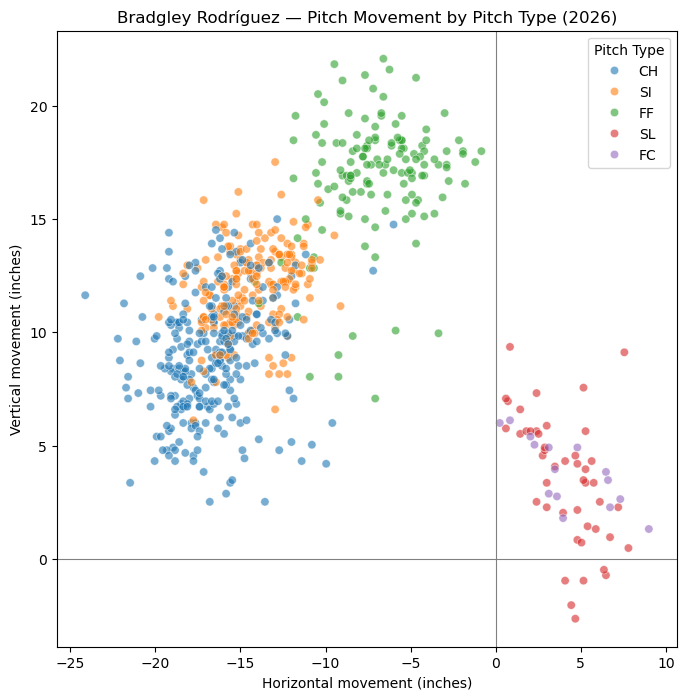

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Statcast stores movement in feet; multiply by 12 to get inches (easier to read)
data["pfx_x_inches"] = data["pfx_x"] * 12
data["pfx_z_inches"] = data["pfx_z"] * 12

plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=data,
    x="pfx_x_inches",
    y="pfx_z_inches",
    hue="pitch_type",
    alpha=0.6
)
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.xlabel("Horizontal movement (inches)")
plt.ylabel("Vertical movement (inches)")
plt.title("Bradgley Rodríguez — Pitch Movement by Pitch Type (2026)")
plt.legend(title="Pitch Type")
plt.savefig("../figures/bradgley_rodriguez_pitch_movement_2026.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Whiff rate and usage by pitch

In [5]:
swings = ["foul", "hit_into_play", "swinging_strike", "swinging_strike_blocked", "foul_tip"]
whiffs = ["swinging_strike", "swinging_strike_blocked", "foul_tip"]

data["is_swing"] = data["description"].isin(swings)
data["is_whiff"] = data["description"].isin(whiffs)

summary = data.groupby("pitch_type").agg(pitches=("pitch_type", "count"), swings=("is_swing", "sum"), whiffs=("is_whiff", "sum"))

summary["whiff_rate"] = (summary["whiffs"] / summary["swings"] * 100).round(1)
summary["usage_%"] = (summary["pitches"] / summary["pitches"].sum() * 100).round(1)

summary = summary.sort_values("usage_%", ascending=False)
print(summary)


            pitches  swings  whiffs  whiff_rate  usage_%
pitch_type                                              
CH              276     149      61        40.9     40.6
SI              201      92      12        13.0     29.6
FF              142      63      18        28.6     20.9
SL               46      22       8        36.4      6.8
FC               15       7       4        57.1      2.2


In [6]:
import pandas as pd

# Pull his 2025 season
data_2025 = statcast_pitcher("2025-03-01", "2025-11-01", 699134)

# Stack 2025 + 2026 into one combined dataset
combined = pd.concat([data_2025, data], ignore_index=True)

print("2025 pitches:", data_2025.shape[0])
print("2026 pitches:", data.shape[0])
print("Combined:", combined.shape[0])
data_2025.to_csv("bradgley_rodriguez_statcast_2025.csv", index=False)

2025 pitches: 150
2026 pitches: 681
Combined: 831


In [7]:
combined["is_swing"] = combined["description"].isin(swings)
combined["is_whiff"] = combined["description"].isin(whiffs)

summary_all = combined.groupby("pitch_type").agg(pitches=("pitch_type", "count"), swings=("is_swing", "sum"), whiffs=("is_whiff", "sum"))

summary_all["whiff_rate"] = (summary_all["whiffs"] / summary_all["swings"] * 100).round(1)
summary_all["usage_%"] = (summary_all["pitches"] / summary_all["pitches"].sum() * 100).round(1)

summary_all = summary_all.sort_values("usage_%", ascending=False)
print(summary_all)

            pitches  swings  whiffs  whiff_rate  usage_%
pitch_type                                              
CH              312     168      69        41.1     37.7
SI              234     107      15        14.0     28.3
FF              202      84      22        26.2     24.4
SL               46      22       8        36.4      5.6
FC               34      18       6        33.3      4.1


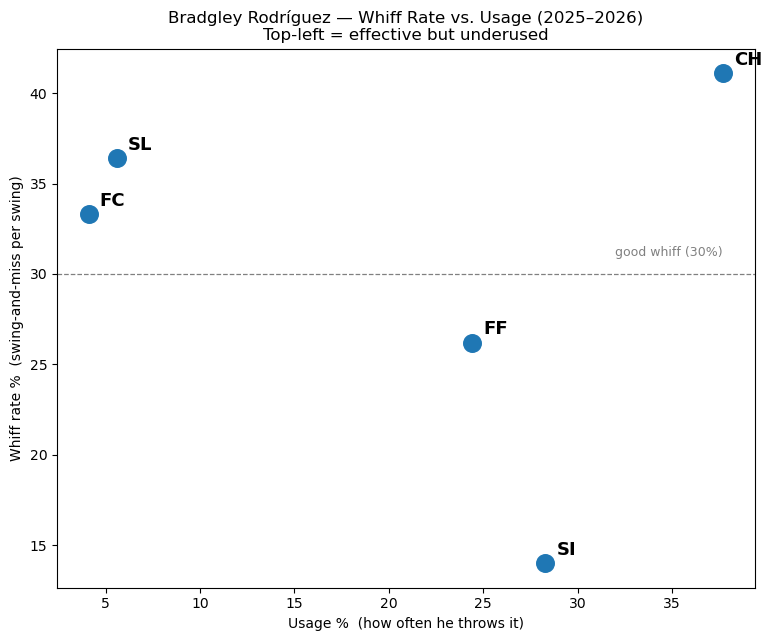

In [8]:
import matplotlib.pyplot as plt

plot_df = summary_all.reset_index()

plt.figure(figsize=(9, 7))
plt.scatter(plot_df["usage_%"], plot_df["whiff_rate"], s=160, color="#1f77b4")

# Label each pitch
for _, row in plot_df.iterrows():
    plt.annotate(
        row["pitch_type"],
        (row["usage_%"], row["whiff_rate"]),
        xytext=(8, 6), textcoords="offset points",
        fontsize=13, fontweight="bold"
    )

# Reference line for an "above-average whiff" pitch
plt.axhline(30, color="gray", linestyle="--", linewidth=0.9)
plt.text(plot_df["usage_%"].max(), 31, "good whiff (30%)", color="gray", ha="right", fontsize=9)

plt.xlabel("Usage %  (how often he throws it)")
plt.ylabel("Whiff rate %  (swing-and-miss per swing)")
plt.title("Bradgley Rodríguez — Whiff Rate vs. Usage (2025–2026)\nTop-left = effective but underused")
plt.savefig("../figures/bradgley_rodriguez_whiff_vs_usage_2026.png", dpi=200, bbox_inches="tight")
plt.show()